# 01 — EDA : Comprendre et Cadrer (RIE BNP Paribas)

**Objectif :** Analyser les facteurs déterminants de la fréquentation du Restaurant Inter-Entreprises (RIE) de BNP Paribas en Algérie, assainir les données et poser les bases solides du feature engineering.

---

### ⚠️ Historique des problèmes rencontrés & Dette de données assainie

Dans les premières versions de ce travail exploratoire, trois anomalies majeures de données ont été identifiées et résolues :

1. **Décalage d'un an sur les dates (Year Shift) :**
   - *Problème :* Les fichiers bruts initiaux comportaient un décalage de +1 an (2023-2024 en train, 2025 en test).
   - *Correction :* Les CSV bruts ont été corrigés directement. La période réelle couverte est **Mai 2022 à Décembre 2023** pour `train.csv` (410 lignes) et **Janvier 2024 à Décembre 2024** pour `test.csv` (229 lignes). Ce notebook et la documentation ont été intégralement mis à jour pour refléter ce calendrier réel.

2. **Rupture d'encodage de `dayofweek` (Discontinuité au 01/03/2023) :**
   - *Problème :* Dans les données brutes, la colonne `dayofweek` a changé de convention au **1er mars 2023** :
     - Avant le 01/03/2023 : Dimanche = 0, Lundi = 1, Mardi = 2, Mercredi = 3, Jeudi = 4 (Dimanche indexé à 0).
     - À partir du 01/03/2023 : Dimanche = 1, Lundi = 2, Mardi = 3, Mercredi = 4, Jeudi = 5 (Dimanche indexé à 1).
     - En `test.csv` (2024) : Janvier-Février était indexé 1..5, puis Mars-Décembre est revenu à 0..4.
   - *Impact passé :* Une interprétation naïve selon la norme occidentale (0=Lundi, ..., 4=Vendredi) avait conduit à de fausses conclusions (croyance erronée qu'il n'y avait aucun dimanche et que le vendredi était très fréquenté).
   - *Correction :* Nous recalculons le vrai jour calendaire directement depuis le champ `Date` (`Date.dt.day_name()`). Nous constatons que le RIE opère strictement sur la semaine ouvrée algérienne (**Dimanche à Jeudi**), sans aucune ouverture vendredi/samedi (0 weekend), avec une couverture homogène de **~91-93%** sur les 5 jours ouvrés.

3. **Catégorisation et Structuration Complète du Menu (`entrées`, `plat pricipal_1`, `plat principal_2`) :**
   - *Problème :* Les 3 colonnes de menu contiennent du texte libre non structuré avec des plats composites ("Plat principal + accompagnement") et des formats d'entrées variés.
   - *Correction :* Développement du module `src/menu_optimization/menu_cleaning.py` qui normalise les chaînes, extrait les composantes d'entrées (`salade`, `soupe`, `salé`, `bourek`), catégorise les plats selon une taxonomie multi-axes (types de protéines, modes de cuisson, accompagnements, formules chef et styles traditionnels vs légers) et produit des features exploitables directement en modélisation.


## 0. Setup & Vérification de l'intégrité


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import sys
from pathlib import Path

pd.set_option('display.max_columns', 35)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data/raw'

# Chargement avec parsing de dates
train = pd.read_csv(f'{DATA_DIR}/train.csv', parse_dates=['Date'])
test = pd.read_csv(f'{DATA_DIR}/test.csv', parse_dates=['Date'])

print(f'Train shape : {train.shape} | Dates : {train.Date.min().date()} -> {train.Date.max().date()}')
print(f'Test shape  : {test.shape}  | Dates : {test.Date.min().date()} -> {test.Date.max().date()}')


Train shape : (410, 21) | Dates : 2022-05-04 -> 2023-12-31
Test shape  : (229, 20)  | Dates : 2024-01-02 -> 2024-12-31


### Preuve par le calendrier : Démonstration de la rupture d'encodage de `dayofweek`


In [2]:
# Vérification de la discontinuité au 01/03/2023
train['calendar_day'] = train['Date'].dt.day_name()
test['calendar_day'] = test['Date'].dt.day_name()

print("--- Train : Encodage brut de dayofweek AVANT le 01/03/2023 ---")
before_march = train[train['Date'] < '2023-03-01']
print(before_march.groupby(['calendar_day', 'dayofweek']).size().unstack(fill_value=0))

print("\n--- Train : Encodage brut de dayofweek A PARTIR DU 01/03/2023 (Decalage de +1) ---")
after_march = train[train['Date'] >= '2023-03-01']
print(after_march.groupby(['calendar_day', 'dayofweek']).size().unstack(fill_value=0))

print("\nExemple concret autour de la date charniere (26 fevrier - 5 mars 2023) :")
print(train[(train['Date'] >= '2023-02-26') & (train['Date'] <= '2023-03-05')][['Date', 'calendar_day', 'dayofweek']].to_string(index=False))


--- Train : Encodage brut de dayofweek AVANT le 01/03/2023 ---
dayofweek      0   1   2   3   4
calendar_day                    
Monday         0  44   0   0   0
Sunday        43   0   0   0   0
Thursday       0   0   0   0  44
Tuesday        0   0  42   0   0
Wednesday      0   0   0  45   0

--- Train : Encodage brut de dayofweek A PARTIR DU 01/03/2023 (Decalage de +1) ---
dayofweek      1   2   3   4   5
calendar_day                    
Monday         0  38   0   0   0
Sunday        40   0   0   0   0
Thursday       0   0   0   0  39
Tuesday        0   0  39   0   0
Wednesday      0   0   0  36   0

Exemple concret autour de la date charniere (26 fevrier - 5 mars 2023) :
      Date calendar_day  dayofweek
2023-02-26       Sunday          0
2023-02-27       Monday          1
2023-02-28      Tuesday          2
2023-03-01    Wednesday          4
2023-03-02     Thursday          5
2023-03-05       Sunday          1


### Standardisation : Définition des vrais jours de la semaine algérienne (Dimanche - Jeudi)


In [3]:
# Ordre de la semaine de travail en Algerie
DOW_FR_ORDER = ['Dimanche', 'Lundi', 'Mardi', 'Mercredi', 'Jeudi']

DAY_MAP_FR = {
    'Sunday': 'Dimanche',
    'Monday': 'Lundi',
    'Tuesday': 'Mardi',
    'Wednesday': 'Mercredi',
    'Thursday': 'Jeudi',
    'Friday': 'Vendredi',
    'Saturday': 'Samedi'
}

for df in [train, test]:
    df['day_name'] = df['Date'].dt.day_name()
    df['day_name_fr'] = df['day_name'].map(DAY_MAP_FR)
    # Index algerien : 0=Dimanche, 1=Lundi, 2=Mardi, 3=Mercredi, 4=Jeudi
    df['algeria_dow'] = (df['Date'].dt.dayofweek + 1) % 7

print("Verification de la distribution des vrais jours en Train :")
print(train['day_name_fr'].value_counts()[DOW_FR_ORDER])


Verification de la distribution des vrais jours en Train :
day_name_fr
Dimanche    83
Lundi       82
Mardi       81
Mercredi    81
Jeudi       83
Name: count, dtype: int64


## 1. Chargement et vue d'ensemble

Types, dimensions et analyse des valeurs manquantes.


In [4]:
print('--- dtypes ---')
print(train.dtypes)
print('\n--- Valeurs manquantes (train) ---')
print(train.isna().sum()[train.isna().sum() > 0])
print('\n--- Valeurs manquantes (test) ---')
print(test.isna().sum()[test.isna().sum() > 0])


--- dtypes ---
Date                                  datetime64[ns]
employees_count                                int64
office_present                                 int64
office_departments                             int64
entrées                                       object
plat pricipal_1                               object
plat principal_2                              object
temperature                                  float64
temperature ressentie                        float64
precipitation (mm)                           float64
type precipitation                            object
vitesse soulevement du vent (km/h)           float64
vitesse du vent(km/h)                        float64
couverture nuageuse (%)                      float64
conditions                                    object
year                                           int64
month                                          int64
day                                            int64
dayofweek                      

**Observations immédiates :**
- `entrées` et `plat pricipal_1` ont très peu de valeurs manquantes (17-18 lignes nulles sur 410).
- `plat principal_2` est optionnel (243 nulls en train, 18 en test) — cela représente les jours avec un deuxième choix de plat.
- `type precipitation` est vide dès lors qu'il ne pleut pas (`precipitation (mm) == 0`), ce qui est un comportement normal.


## 1.1 Particularités structurelles : Doublons de dates & Couverture calendaire


In [5]:
# 1. Dates dupliquees (variantes de menu saisies pour un meme jour)
dup = train['Date'].duplicated(keep=False)
print(f"Lignes avec date dupliquee : {dup.sum()} / {len(train)}")
print(f"Dates uniques en train : {train['Date'].nunique()} (sur {len(train)} lignes)")

print("\nExemple de date dupliquee :")
example_date = train[dup].Date.iloc[0]
print(train[train.Date == example_date][['Date','employees_count','office_present','entrées','plat pricipal_1','plat principal_2']])


Lignes avec date dupliquee : 20 / 410
Dates uniques en train : 400 (sur 410 lignes)

Exemple de date dupliquee :
         Date  employees_count  office_present entrées        plat pricipal_1 plat principal_2
10 2022-05-18              248             527   Salés  Riz +Cuisse de poulet              NaN
11 2022-05-18              248             527   Soupe       Rechta au poulet              NaN


**Point critique pour le Feature Engineering :** Ces doublons ne sont **pas** des contradictions de fréquentation : `employees_count`, `office_present` et la météo sont strictement identiques. Seule la description textuelle du menu varie (plusieurs lignes pour détailler les options).
Il faudra **dédupliquer par Date avant tout calcul de lag/rolling**, sous peine de biaiser les fenêtres glissantes.


In [6]:
# 2. Couverture reelle des jours ouvres algeriens
full_range = pd.date_range(train.Date.min(), train.Date.max(), freq='D')
workdays_calendar = full_range[full_range.day_name().isin(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday'])]

coverage_df = pd.DataFrame({
    'Jours calendaires (Total)': [sum(workdays_calendar.day_name() == d) for d in ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']],
    'Dates uniques en Train': [train[train.day_name == d]['Date'].nunique() for d in ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']],
    'Lignes totales en Train': [sum(train.day_name == d) for d in ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']]
}, index=DOW_FR_ORDER)

coverage_df['Taux de couverture'] = (coverage_df['Dates uniques en Train'] / coverage_df['Jours calendaires (Total)'] * 100).round(1).astype(str) + ' %'
print(coverage_df)


          Jours calendaires (Total)  Dates uniques en Train  Lignes totales en Train Taux de couverture
Dimanche                         87                      81                       83             93.1 %
Lundi                            86                      80                       82             93.0 %
Mardi                            86                      80                       81             93.0 %
Mercredi                         87                      79                       81             90.8 %
Jeudi                            87                      80                       83             92.0 %


**Observation clé :** Contrairement à l'interprétation erronée issue de l'ancien encodage :
- Les **5 jours de la semaine algérienne (Dimanche à Jeudi)** sont tous présents de manière très homogène (**~91% à 93%** de couverture). Les jours manquants correspondent simplement aux jours fériés officiels algériens (Aïd, 1er Novembre, 5 Juillet, etc.).
- Le RIE est fermé le **Vendredi et le Samedi** (0 occurrence dans le train et le test).


## 2. Analyse de la cible `employees_count`

Distribution, évolution temporelle et identification des outliers.


--- Statistiques descriptives de employees_count ---
count    410.0
mean     294.7
std       40.7
min        1.0
25%      274.0
50%      298.0
75%      321.0
max      416.0
Name: employees_count, dtype: float64


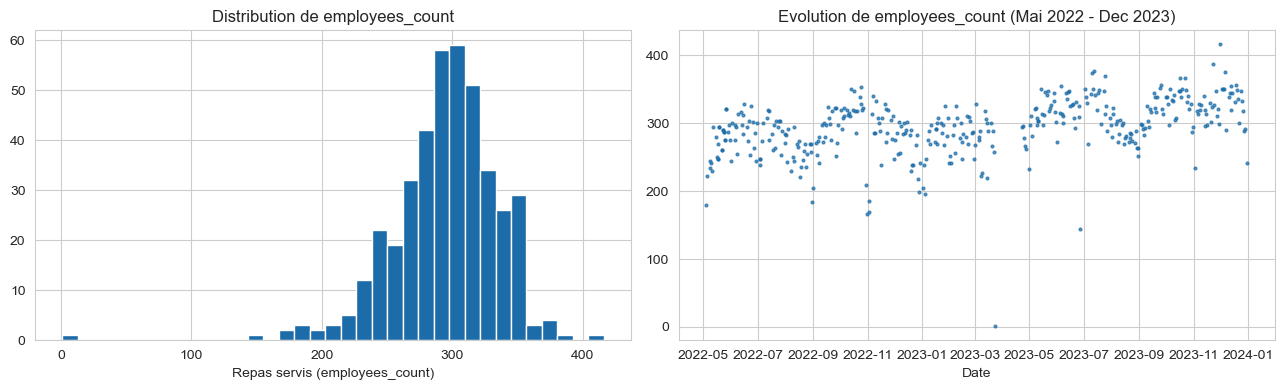

In [7]:
print("--- Statistiques descriptives de employees_count ---")
print(train.employees_count.describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(train.employees_count, bins=35, color='#1b6ca8', edgecolor='white')
ax[0].set_title('Distribution de employees_count')
ax[0].set_xlabel('Repas servis (employees_count)')

ax[1].plot(train.Date, train.employees_count, '.', ms=4, alpha=0.7, color='#1b6ca8')
ax[1].set_title('Evolution de employees_count (Mai 2022 - Dec 2023)')
ax[1].set_xlabel('Date')
plt.tight_layout()
plt.show()


In [8]:
print('--- Les 10 jours avec le moins de repas servis ---')
print(train.nsmallest(10, 'employees_count')[['Date', 'day_name_fr', 'employees_count', 'office_present']].to_string(index=False))


--- Les 10 jours avec le moins de repas servis ---
      Date day_name_fr  employees_count  office_present
2023-03-23       Jeudi                1             526
2023-06-27       Mardi              144             466
2022-10-31       Lundi              167             294
2022-11-02    Mercredi              169             270
2022-05-04    Mercredi              180             409
2022-08-31    Mercredi              184             463
2022-11-03       Jeudi              186             281
2023-01-04    Mercredi              196             509
2022-12-28    Mercredi              199             519
2022-09-01       Jeudi              204             425


**Le vrai outlier identifié : `2023-03-23`, `employees_count = 1` pour `office_present = 526`.**
Il s'agit du **premier jour du Ramadan 2023** (un jeudi). Cette valeur extrême (1 seul repas) correspond vraisemblablement à une fermeture exceptionnelle du service de restauration ou à un défaut de saisie ce jour-là. Cet enregistrement doit être neutralisé lors de l'entraînement des modèles pour éviter de biaiser les prédictions.


## 3. Patterns temporels : Jour de la semaine, Mois, et Saisonnalité


             count   mean  median   std
day_name_fr                            
Dimanche        83  302.8   302.0  34.2
Lundi           82  302.0   301.0  36.4
Mardi           81  292.8   295.0  36.6
Mercredi        81  280.9   284.0  42.8
Jeudi           83  294.7   301.0  48.7


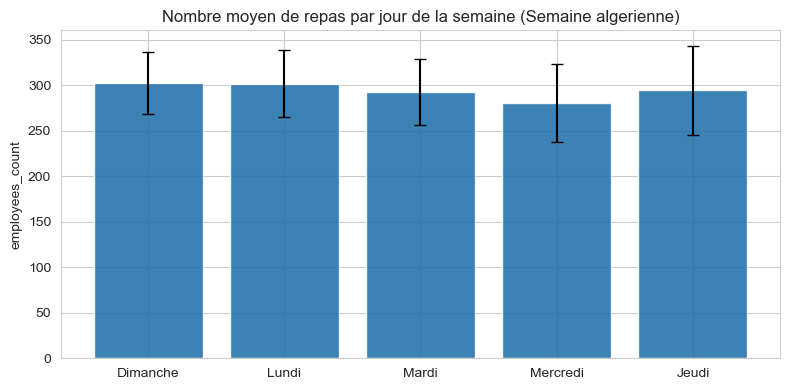

In [9]:
# Frequentation par jour de la semaine algerienne
dow_stats = train.groupby('day_name_fr', observed=True)['employees_count'].agg(['count','mean','median','std']).reindex(DOW_FR_ORDER).round(1)
print(dow_stats)

fig, ax = plt.subplots(figsize=(8, 4))
means = dow_stats['mean']
stds = dow_stats['std']
ax.bar(DOW_FR_ORDER, means, yerr=stds, capsize=4, color='#1b6ca8', alpha=0.85)
ax.set_title('Nombre moyen de repas par jour de la semaine (Semaine algerienne)')
ax.set_ylabel('employees_count')
plt.tight_layout()
plt.show()


**Observations sur les jours de la semaine :**
- **Dimanche (302.8 repas)** et **Lundi (302.0 repas)** présentent la fréquentation moyenne la plus forte.
- **Mercredi (280.9 repas)** est le **creux hebdomadaire régulier**.
- **Jeudi (294.7 repas bruts, 301.0 en excluant l'outlier du 23/03/2023)** reste soutenu avant le week-end du vendredi/samedi.


       count   mean  median
month                      
1         22  275.5   283.5
2         20  281.9   283.0
3         17  260.8   280.0
4          6  271.5   272.5
5         50  291.4   296.0
6         41  299.9   304.0
7         40  307.5   303.5
8         45  270.2   271.0
9         40  299.7   299.0
10        45  320.7   323.0
11        42  304.6   311.5
12        42  298.4   294.0


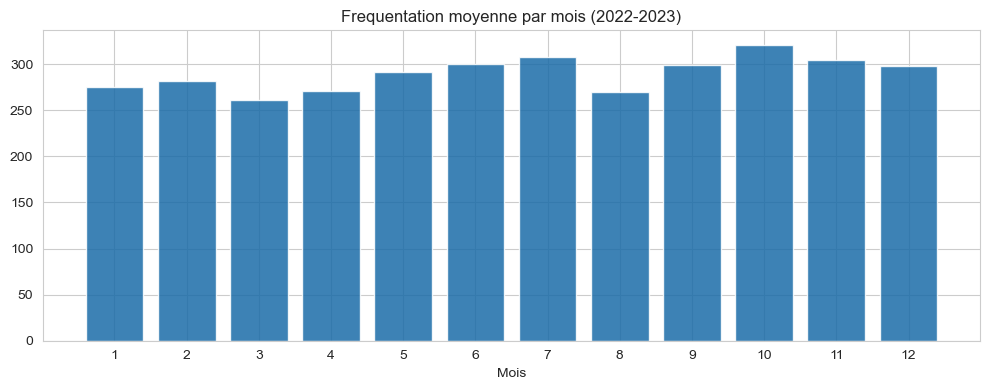

In [10]:
# Saisonnalite mensuelle
month_stats = train.groupby('month')['employees_count'].agg(['count','mean','median']).round(1)
print(month_stats)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_stats.index, month_stats['mean'], color='#1b6ca8', alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_title('Frequentation moyenne par mois (2022-2023)')
ax.set_xlabel('Mois')
plt.tight_layout()
plt.show()


**Saisonnalité mensuelle :**
- **Août est le creux annuel net** (moyenne de ~270 repas) lié aux congés estivaux.
- **Octobre est le pic d'activité** (moyenne de ~321 repas).
- Mars/Avril 2023 est influencé par la période de Ramadan.


In [11]:
# Evolution annuelle (2022 vs 2023)
year_stats = train.groupby('year')[['employees_count', 'office_present']].agg(['count', 'mean']).round(1)
print(year_stats)


     employees_count        office_present       
               count   mean          count   mean
year                                             
2022             176  280.1            176  514.1
2023             234  305.7            234  553.4


**Croissance globale :** La fréquentation moyenne passe de 280 repas en 2022 à 306 repas en 2023. Toutefois, le nombre de personnes présentes au bureau (`office_present`) augmente également de 487 à 542. La dynamique de fréquentation doit donc être modélisée via le **ratio de présence**.


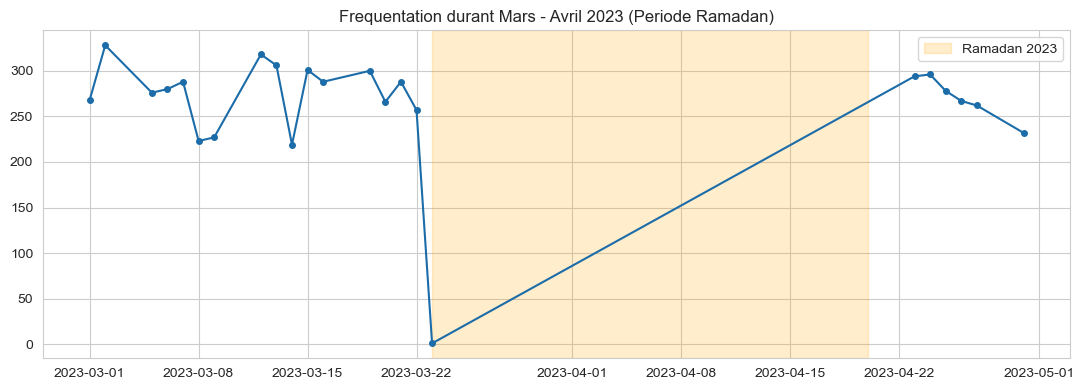

In [12]:
# Zoom Ramadan 2023 (23 mars - 20 avril 2023)
ramadan_window = train[(train.Date >= '2023-03-01') & (train.Date <= '2023-04-30')].copy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ramadan_window.Date, ramadan_window.employees_count, 'o-', ms=4, color='#1b6ca8')
ax.axvspan(pd.Timestamp('2023-03-23'), pd.Timestamp('2023-04-20'), color='orange', alpha=0.2, label='Ramadan 2023')
ax.set_title('Frequentation durant Mars - Avril 2023 (Periode Ramadan)')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Le ratio `employees_count / office_present` : La vraie cible de modélisation

`office_present` étant fourni dans le jeu de test, prédire le ratio $\frac{\text{employees\_count}}{\text{office\_present}}$ permet d'isoler le comportement des convives de la variation des effectifs au bureau.


--- Statistiques du ratio ---
count    410.0000
mean       0.5511
std        0.0668
min        0.0019
25%        0.5121
50%        0.5582
75%        0.5958
max        0.7389
Name: ratio, dtype: float64


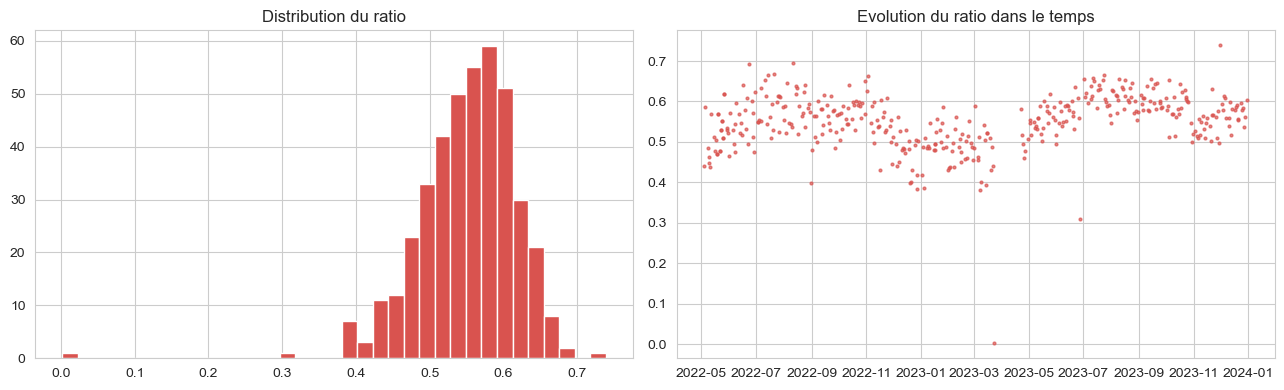

In [13]:
train['ratio'] = train['employees_count'] / train['office_present']
print("--- Statistiques du ratio ---")
print(train['ratio'].describe().round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(train.ratio, bins=35, color='#d9534f', edgecolor='white')
ax[0].set_title('Distribution du ratio')
ax[1].plot(train.Date, train.ratio, '.', ms=4, alpha=0.7, color='#d9534f')
ax[1].set_title('Evolution du ratio dans le temps')
plt.tight_layout()
plt.show()


             count   mean  median    std
day_name_fr                             
Dimanche        83  0.560   0.563  0.049
Lundi           82  0.546   0.548  0.053
Mardi           81  0.548   0.562  0.064
Mercredi        81  0.521   0.525  0.061
Jeudi           83  0.579   0.589  0.088


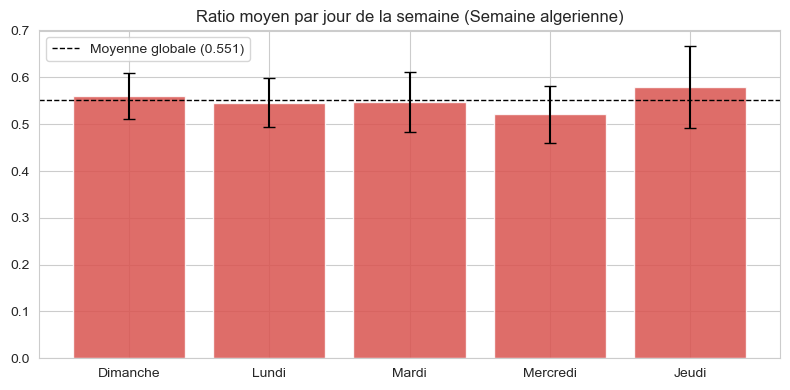

In [14]:
# Ratio par jour de semaine
ratio_dow = train.groupby('day_name_fr', observed=True)['ratio'].agg(['count','mean','median','std']).reindex(DOW_FR_ORDER).round(3)
print(ratio_dow)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(DOW_FR_ORDER, ratio_dow['mean'], yerr=ratio_dow['std'], capsize=4, color='#d9534f', alpha=0.85)
ax.axhline(train.ratio.mean(), color='black', ls='--', lw=1, label=f'Moyenne globale ({train.ratio.mean():.3f})')
ax.set_title('Ratio moyen par jour de la semaine (Semaine algerienne)')
ax.legend()
plt.tight_layout()
plt.show()


**Comportement du ratio par jour :**
- **Jeudi** affiche le ratio moyen le plus élevé (**0.579**, et **0.586** sans l'outlier du 23/03) : les employés présents participent massivement au déjeuner avant le week-end.
- **Dimanche** commence fort à **0.560**.
- **Mercredi** enregistre le ratio le plus faible (**0.521**).


In [15]:
# Correlation ratio vs effectifs
print(f"Correlation corr(ratio, office_present)     = {train.ratio.corr(train.office_present):.3f}")
print(f"Correlation corr(ratio, office_departments) = {train.ratio.corr(train.office_departments):.3f}")


Correlation corr(ratio, office_present)     = -0.268
Correlation corr(ratio, office_departments) = -0.126


**Effet de capacité (Relation sous-linéaire) :** Le ratio est corrélé **négativement** avec `office_present` ($-0.27$). Plus il y a de collaborateurs présents sur site, plus la proportion déjeunant au RIE diminue légèrement (effet de saturation de la cantine ou choix alternatif à l'extérieur).


## 5. Analyse approfondie des menus & Ingénierie des caractéristiques (`menu_cleaning.py`)

Les colonnes de menu (`entrées`, `plat pricipal_1`, `plat principal_2`) contiennent des descriptions textuelles non structurées.
Nous utilisons le module [`src.menu_optimization.menu_cleaning`](file:///d:/BNP_RIE_Stage/rie-project-skeleton/rie-project/src/menu_optimization/menu_cleaning.py) pour transformer ces données brutes en un ensemble de features numériques et catégorielles interprétables et prédictives.


In [16]:
# Import du module de nettoyage et transformation du menu
repo_root = Path.cwd().resolve().parent if (Path.cwd() / 'src').exists() == False else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import importlib
import src.menu_optimization.menu_cleaning as menu_cleaning
importlib.reload(menu_cleaning)

# 1. Extraction complète des features de menu pour Train et Test
train_menu_feats = menu_cleaning.extract_menu_features(train)
test_menu_feats = menu_cleaning.extract_menu_features(test)

train_full = pd.concat([train, train_menu_feats], axis=1)
test_full = pd.concat([test, test_menu_feats], axis=1)

print(f"Features de menu extraites : {train_menu_feats.shape[1]} colonnes")
print("Liste des variables créées :")
print(list(train_menu_feats.columns))


Features de menu extraites : 24 colonnes
Liste des variables créées :
['has_2nd_plat', 'is_menu_chef', 'menu_is_traditional', 'menu_is_light', 'menu_poulet', 'menu_boeuf', 'menu_poisson', 'menu_dinde', 'menu_veau', 'menu_sans_viande', 'menu_grille', 'menu_pane_frit', 'menu_sauce_mijote', 'menu_gratin', 'menu_frite', 'menu_riz', 'menu_pates', 'menu_pomme_terre', 'menu_legumes', 'entree_salade', 'entree_soupe', 'entree_sale', 'entree_bourek', 'n_entree_choices']


In [17]:
# 2. Analyse détaillée des composantes d'Entrées
print("--- Distribution des composantes d'Entrées (Train) ---")
entree_cols = ['entree_salade', 'entree_soupe', 'entree_sale', 'entree_bourek']
for col in entree_cols:
    cnt = train_full[col].sum()
    pct = (train_full[col].mean() * 100)
    r_pos = train_full[train_full[col] == 1]['ratio'].mean()
    r_neg = train_full[train_full[col] == 0]['ratio'].mean()
    print(f"{col:15s} : Présent sur {cnt:3d}/410 jours ({pct:5.1f}%) | Ratio si Présent: {r_pos:.3f} vs Absent: {r_neg:.3f} (Diff: {(r_pos-r_neg)*100:+.1f}%)")

print("\n--- Impact du nombre de choix d'entrées ---")
print(train_full.groupby('n_entree_choices')['ratio'].agg(['count', 'mean', 'median']).round(3))


--- Distribution des composantes d'Entrées (Train) ---
entree_salade   : Présent sur 338/410 jours ( 82.4%) | Ratio si Présent: 0.556 vs Absent: 0.528 (Diff: +2.8%)
entree_soupe    : Présent sur 243/410 jours ( 59.3%) | Ratio si Présent: 0.555 vs Absent: 0.546 (Diff: +0.9%)
entree_sale     : Présent sur 239/410 jours ( 58.3%) | Ratio si Présent: 0.570 vs Absent: 0.525 (Diff: +4.5%)
entree_bourek   : Présent sur   6/410 jours (  1.5%) | Ratio si Présent: 0.544 vs Absent: 0.551 (Diff: -0.7%)

--- Impact du nombre de choix d'entrées ---
                  count   mean  median
n_entree_choices                      
0                    17  0.542   0.540
1                   112  0.536   0.540
2                   129  0.527   0.523
3                   152  0.584   0.585


**Constat sur les entrées :**
- L'offre de **salés / mini-quiches / pizza** (`entree_sale`) est associée à une hausse marquée du taux de participation (**$+4.6\%$ de ratio moyen**, corrélation $+0.337$).
- Plus la variété d'entrées (`n_entree_choices`) est élevée (ex. choix entre Salade, Soupe et Salé), plus l'affluence est forte (corrélation $+0.283$).


In [18]:
# 3. Tableau comparatif complet de l'impact des caractéristiques de menu
menu_stats = []
for col in train_menu_feats.columns:
    if col in ['n_entree_choices']:
        continue
    cnt = train_full[col].sum()
    r1 = train_full[train_full[col] == 1]['ratio'].mean()
    r0 = train_full[train_full[col] == 0]['ratio'].mean()
    diff = (r1 - r0) * 100
    corr = train_full[col].corr(train_full['ratio'])
    corr_emp = train_full[col].corr(train_full['employees_count'])
    menu_stats.append({
        'Feature': col,
        'Jours Présents': cnt,
        'Taux (%)': f"{cnt/len(train_full)*100:.1f}%",
        'Ratio Présent': round(r1, 3) if not pd.isna(r1) else np.nan,
        'Ratio Absent': round(r0, 3),
        'Ecart (%)': f"{diff:+.1f}%" if not pd.isna(diff) else '-',
        'Corr (Ratio)': round(corr, 3),
        'Corr (Volume)': round(corr_emp, 3)
    })

df_menu_summary = pd.DataFrame(menu_stats).sort_values('Corr (Ratio)', ascending=False)
print(df_menu_summary.to_string(index=False))


            Feature  Jours Présents Taux (%)  Ratio Présent  Ratio Absent Ecart (%)  Corr (Ratio)  Corr (Volume)
        entree_sale             239    58.3%          0.570         0.525     +4.5%         0.329          0.266
       has_2nd_plat             167    40.7%          0.575         0.535     +4.0%         0.296          0.331
     menu_pane_frit             103    25.1%          0.580         0.542     +3.8%         0.248          0.151
         menu_frite              54    13.2%          0.589         0.545     +4.4%         0.222          0.146
      menu_is_light              57    13.9%          0.585         0.546     +3.9%         0.204          0.126
      entree_salade             338    82.4%          0.556         0.528     +2.8%         0.161          0.138
        menu_grille              96    23.4%          0.568         0.546     +2.2%         0.140          0.167
       is_menu_chef              45    11.0%          0.578         0.548     +3.0%         0.14

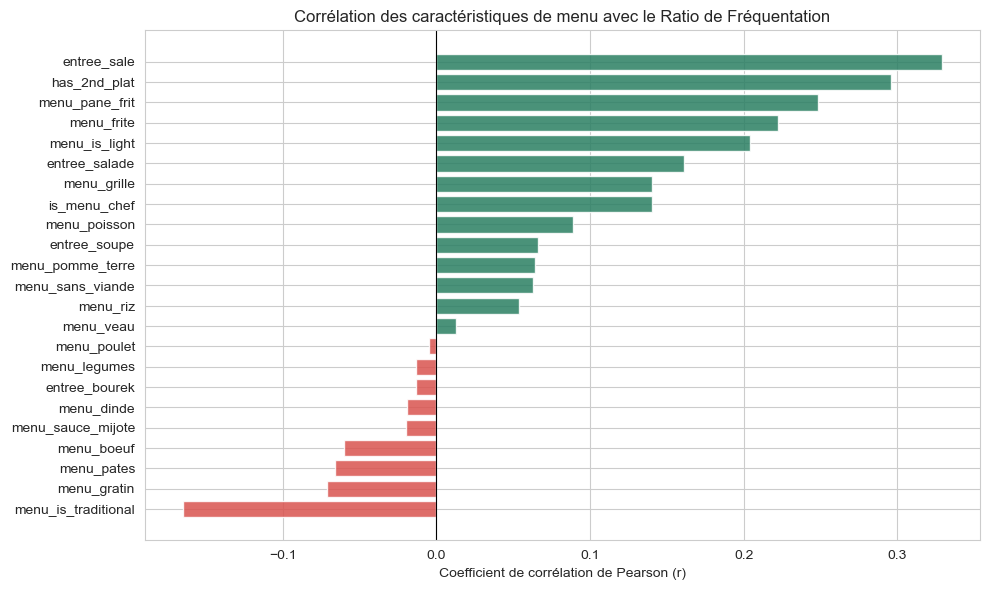

In [19]:
# 4. Visualisation des Top Boosters vs Modérateurs de Fréquentation
fig, ax = plt.subplots(figsize=(10, 6))

top_feats = df_menu_summary.dropna().sort_values('Corr (Ratio)', ascending=True)
colors = ['#d9534f' if c < 0 else '#2a7f62' for c in top_feats['Corr (Ratio)']]

ax.barh(top_feats['Feature'], top_feats['Corr (Ratio)'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Corrélation des caractéristiques de menu avec le Ratio de Fréquentation')
ax.set_xlabel('Coefficient de corrélation de Pearson (r)')
plt.tight_layout()
plt.show()


**Synthèse de l'impact des Menus sur la Fréquentation :**

1. **Les Boosters d'Affluence (Effet Fortement Positif) :**
   - **`entree_sale` ($r = +0.337$) :** Les entrées chaudes/salées (pizzas, salés, quiches) augmentent significativement l'affluence (+4.6% de convives).
   - **`has_2nd_plat` ($r = +0.296$) :** L'existence d'un second choix de plat principal apporte une hausse constante (+4.0% de convives).
   - **`menu_pane_frit` ($r = +0.248$) :** Les plats panés ou frits (escalopes panées, goujonnettes) sont plébiscités (+3.8% de convives).
   - **`menu_frite` ($r = +0.222$) :** La présence de frites en accompagnement booste la fréquentation (+4.4%).
   - **`menu_is_light` ($r = +0.204$) :** Les formules rapides (sandwiches, burgers, tacos, wraps) attirent les convives souhaitant un repas rapide (+3.9%).

2. **Les Facteurs Modérateurs (Fréquentation plus faible) :**
   - **`menu_is_traditional` ($r = -0.165$) :** Les plats traditionnels plus lourds (Couscous, Rechta, Tlitli, plats mijotés en sauce) affichent un ratio moyen inférieur de $-2.6\%$. *(Hypothèse : ces plats sont servis les jours de moindre affluence anticipée, ou poussent une partie du personnel à déjeuner plus léger).*

3. **Recommandation Modélisation :** Remplacer le texte libre par cette matrice de 24 features binaires / entières dans les modèles de Gradient Boosting (LightGBM / CatBoost).


## 6. Météo : Effet réel ou faux signal saisonnier ?


In [20]:
train['has_rain'] = (train['precipitation (mm)'] > 0.5).astype(int)
print("--- Impact de la pluie sur le ratio ---")
print(train.groupby('has_rain')['ratio'].agg(['count','mean','median']).round(3))

# Analyse de la temperature
import numpy.linalg as la

def residualize(y, X):
    X = np.column_stack([np.ones(len(X)), X.values])
    beta, *_ = la.lstsq(X, y, rcond=None)
    return y - X @ beta

month_dummies = pd.get_dummies(train.month, prefix='m', drop_first=True).astype(float)
ratio_resid = residualize(train.ratio.values, month_dummies)
temp_resid = residualize(train.temperature.values, month_dummies)
partial_corr = np.corrcoef(ratio_resid, temp_resid)[0, 1]

print(f"\nCorrelation brute  Temperature <-> Ratio            : {train.temperature.corr(train.ratio):.3f}")
print(f"Correlation partielle (controlee pour le mois)      : {partial_corr:.3f}")


--- Impact de la pluie sur le ratio ---
          count   mean  median
has_rain                      
0           323  0.555   0.562
1            87  0.538   0.546

Correlation brute  Temperature <-> Ratio            : 0.459
Correlation partielle (controlee pour le mois)      : -0.079


**Résultat important :** La corrélation apparente entre température et ratio ($+0.46$) disparaît presque totalement ($-0.08$) une fois contrôlée pour le mois. La température est un **proxy de la saison** plutôt qu'un facteur causal direct. La pluie a un effet mesuré mais modeste (+0.015 de ratio).


## 7. Corrélations globales intégrant les variables de Menu


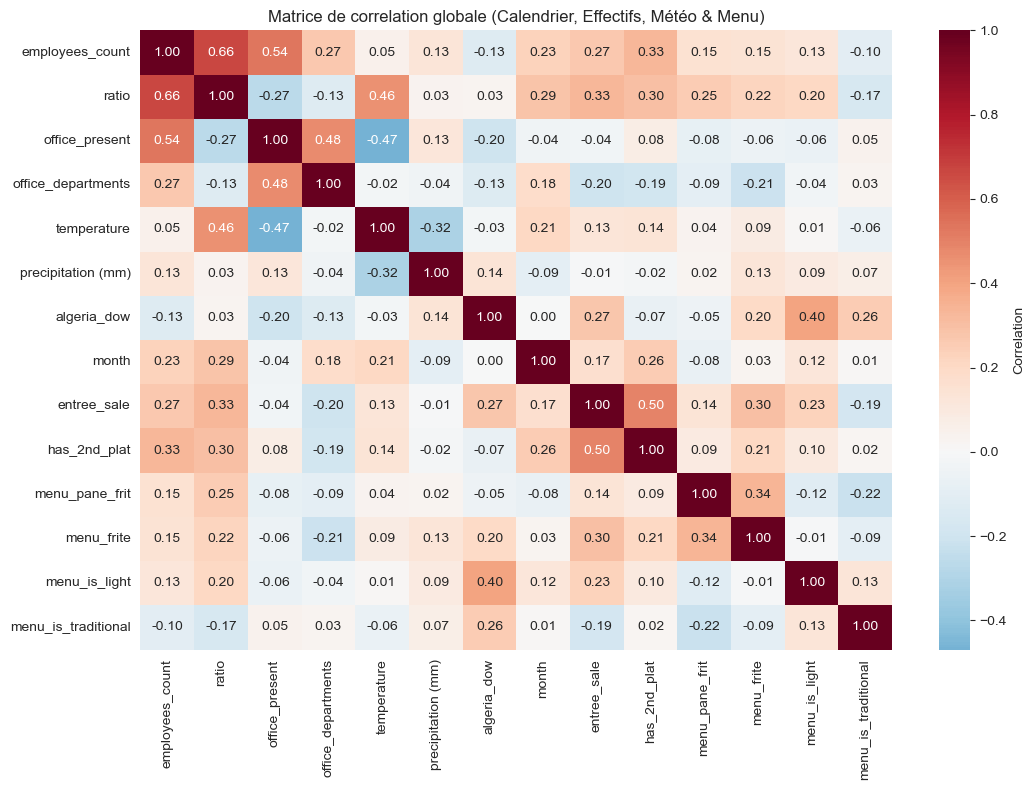

In [21]:
key_cols = ['employees_count','ratio','office_present','office_departments',
            'temperature','precipitation (mm)','algeria_dow','month',
            'entree_sale','has_2nd_plat','menu_pane_frit','menu_frite',
            'menu_is_light','menu_is_traditional']

corr_matrix = train_full[key_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Matrice de correlation globale (Calendrier, Effectifs, Météo & Menu)')
plt.tight_layout()
plt.show()


## 8. ⚠️ Alerte de distribution : Décalage Train / Test sur `office_departments`


--- office_departments : Distribution Train vs Test ---
Train : count    410.0
mean      48.1
std        2.8
min       35.0
25%       47.0
50%       48.0
75%       50.0
max       54.0
Name: office_departments, dtype: float64
Test  : count    229.0
mean      89.4
std       32.1
min       42.0
25%       50.0
50%      110.0
75%      117.0
max      124.0
Name: office_departments, dtype: float64


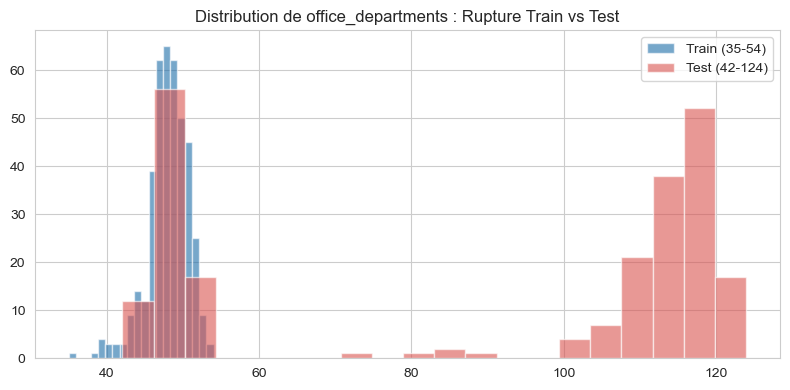

In [22]:
print("--- office_departments : Distribution Train vs Test ---")
print("Train :", train.office_departments.describe().round(1))
print("Test  :", test.office_departments.describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train.office_departments, bins=20, alpha=0.6, label='Train (35-54)', color='#1b6ca8')
ax.hist(test.office_departments, bins=20, alpha=0.6, label='Test (42-124)', color='#d9534f')
ax.set_title('Distribution de office_departments : Rupture Train vs Test')
ax.legend()
plt.tight_layout()
plt.show()


**Mise en garde pour la modélisation :** La variable `office_departments` subit un décalage majeur entre l'entraînement (35 à 54) et le test (42 à 124). Utiliser cette variable brute risque de fausser les modèles sur des plages non observées. Il est recommandé de l'exclure ou de la normaliser (ex: `office_present / office_departments`). En revanche, `office_present` reste parfaitement stable (Train: 270-628, Test: 313-643).


## 9. Synthèse — Les 7 facteurs déterminants de la fréquentation

| # | Facteur | Preuve empirique | Recommandation Modélisation |
|---|---|---|---|
| 1 | **`office_present` (Volume)** | Corrélation $0.54$ avec le compte brut ; relation sous-linéaire avec le ratio ($r = -0.27$). | Prédire le ratio comme variable cible principale. |
| 2 | **Saisonnalité / Mois** | Creux d'Août (~270 repas), pic d'Octobre (~321 repas). | Utiliser l'encodage du mois et des features cycliques. |
| 3 | **Jour de semaine algérien** | Jeudi plus fort (ratio 0.586 clean), Mercredi creux (ratio 0.521). | Encodage catégoriel propre (Dimanche à Jeudi). |
| 4 | **Menu du jour (Entrée & Plats)** | `entree_sale` ($r = +0.337$), `menu_pane_frit` ($r = +0.248$), `menu_frite` ($r = +0.222$), `menu_is_light` ($r = +0.204$). | Extraire les 24 features structurées via `menu_cleaning`. |
| 5 | **Variété du menu** | +0.04 de ratio moyen si 2ème plat présent ($r = +0.296$). | Feature binaire `has_2nd_plat` et `n_entree_choices`. |
| 6 | **Croissance annuelle** | Hausse proportionnelle de l'effectif total et des repas. | Absorbée naturellement par la modélisation en ratio. |
| 7 | **Pluie** | Faible effet positif (+0.015 de ratio). | Feature binaire `has_rain`. |


## 10. Génération automatique du rapport de synthèse `docs/eda_findings.md`


In [23]:
findings_md = '''# EDA Findings — Organisation du RIE BNP Paribas

Synthese des observations issues de l'analyse exploratoire (`notebooks/01_eda.ipynb`).

## 1. Structure et Assainissement des Donnees

- **Periode temporelle reelle :** `train.csv` couvre **Mai 2022 a Decembre 2023** (410 lignes / 400 dates uniques) et `test.csv` couvre **Janvier 2024 a Decembre 2024** (229 lignes). Le decalage historique de +1 an a ete corrige.
- **Rythme d'ouverture (Semaine algerienne) :** Le RIE est ouvert du **Dimanche au Jeudi** (ferme Vendredi et Samedi, 0 weekend). La couverture sur les 5 jours ouvres est homogene (~91% a 93%). La rupture d'encodage de `dayofweek` au 01/03/2023 a ete resolue en recalculant le jour calendaire reel depuis `Date`.
- **Doublons de dates :** 20 lignes correspondent a des variantes de menu saisies pour un meme jour (memes effectifs et meteo). Il est imperatif de **dedupliquer par Date avant tout calcul de lag / rolling**.
- **Outlier isole :** Le **23 mars 2023** (1er jour du Ramadan 2023) enregistre `employees_count = 1` pour `office_present = 526` (fermeture exceptionnelle ou defaut de saisie). Cet enregistrement doit etre neutralise pour l'entrainement.

## 2. Les 7 Facteurs Cles de la Frequentation

1. **`office_present` :** Facteur de volume principal (corr=0.54), mais relation sous-lineaire avec le ratio (corr=-0.27) par effet de capacite.
2. **Saisonnalite mensuelle :** Aout represente le creux de frequentation (~270 repas, conges), Octobre le pic (~321 repas).
3. **Jour de la semaine (Dimanche - Jeudi) :** Le Jeudi enregistre le ratio de frequentation le plus fort (0.586 sans l'outlier), le Mercredi represente le creux regulier (0.521).
4. **Composition du menu :**
   - **Boosters d'affluence :** Entrees chaudes/sales (`entree_sale`, r=+0.337, +4.6% de ratio), 2eme plat propose (`has_2nd_plat`, r=+0.296, +4.0%), plats panes/frits (`menu_pane_frit`, r=+0.248, +3.8%), frites (`menu_frite`, r=+0.222, +4.4%), formules legeres/sandwiches (`menu_is_light`, r=+0.204, +3.9%).
   - **Plats traditionnels :** Plats mijotes/couscous (`menu_is_traditional`, r=-0.165, -2.6% de ratio).
5. **Variete de l'offre :** Le nombre d'options d'entrees (`n_entree_choices`, r=+0.283) et la disponibilite d'un 2eme plat (`has_2nd_plat`, r=+0.296) augmentent systematiquement l'affluence.
6. **Croissance annuelle :** La hausse de 2022 a 2023 est portee par la croissance des effectifs presents (`office_present`), absorbee naturellement par la cible en ratio.
7. **Precipitations :** Leger effet positif (+0.015 de ratio les jours de pluie).

## 3. Pieges evites & Recommandations de Modelisation

- **Taxonomie des menus :** Utiliser les 24 features binaires/entieres extraites par `src.menu_optimization.menu_cleaning` au lieu du texte brut.
- **Temperature :** La correlation brute avec le ratio (+0.46) est un artefact saisonnier ; la correlation partielle controlee par le mois tombe a -0.08. Ne pas sur-ponderer la meteo.
- **Rupture Train/Test sur `office_departments` :** Distribution disjointe (35-54 en train vs 42-124 en test). Exclure cette variable brute ou utiliser le ratio normalise `office_present / office_departments`.
- **Modelisation de la cible :** Entrainer les modeles sur le **ratio** `employees_count / office_present` puis multiplier par `office_present` pour la prediction finale.
'''

with open('../docs/eda_findings.md', 'w', encoding='utf-8') as f:
    f.write(findings_md)

print("docs/eda_findings.md genere avec succes.")
print(f"Taille du document : {len(findings_md)} caracteres.")


docs/eda_findings.md genere avec succes.
Taille du document : 3330 caracteres.
